In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# make plots appear inline
%matplotlib inline

In [4]:
# Load the CSV file
df = pd.read_csv("airbnb_listings.csv")

In [5]:
# Basic overview
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (1000, 17)

First 5 rows:


,listing_id,city,neighborhood,room_type,property_type,bedrooms,bathrooms,accommodates,review_score,number_of_reviews,host_response_rate,availability_365,cancellation_policy,amenities_count,latitude,longitude,price
0,1,Seattle,Downtown,Private room,Villa,1,1,1,4.31,401,97,314,Flexible,10,-45.143321,-75.101621,274.75
1,2,Chicago,City Center,Private room,Apartment,1,3,6,3.08,21,67,296,Moderate,7,-28.464192,116.185135,368.79
2,3,Boston,Harbor Area,Shared room,Townhouse,1,1,6,4.26,65,90,111,Moderate,7,-59.713120,-17.493239,416.95
3,4,Miami,Suburb,Private room,Condo,4,1,3,3.27,20,97,229,Moderate,10,14.697240,0.521071,473.79
4,5,Seattle,Uptown,Private room,Apartment,5,2,8,3.11,99,94,95,Strict,7,85.581094,7.498343,436.33


In [6]:
print("\nColumn info:")
df.info()


Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           1000 non-null   int64  
 1   city                 1000 non-null   object 
 2   neighborhood         1000 non-null   object 
 3   room_type            1000 non-null   object 
 4   property_type        1000 non-null   object 
 5   bedrooms             1000 non-null   int64  
 6   bathrooms            1000 non-null   int64  
 7   accommodates         1000 non-null   int64  
 8   review_score         1000 non-null   float64
 9   number_of_reviews    1000 non-null   int64  
 10  host_response_rate   1000 non-null   int64  
 11  availability_365     1000 non-null   int64  
 12  cancellation_policy  1000 non-null   object 
 13  amenities_count      1000 non-null   int64  
 14  latitude             1000 non-null   float64
 15  longitude            1000

In [7]:
print("\nSummary statistics:")
display(df.describe())


Summary statistics:


,listing_id,bedrooms,bathrooms,accommodates,review_score,number_of_reviews,host_response_rate,availability_365,amenities_count,latitude,longitude,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.985000,2.010000,5.070000,3.742460,252.568000,74.243000,182.15400,5.914000,-0.021922,-0.134029,411.076690
std,288.819436,1.416609,0.821325,2.530119,0.714379,145.020683,14.396917,104.65499,2.588688,51.823251,103.377387,100.166285
min,1.000000,1.000000,1.000000,1.000000,2.510000,0.000000,50.000000,0.00000,2.000000,-89.756006,-179.933330,165.790000
25%,250.750000,2.000000,1.000000,3.000000,3.130000,129.000000,61.000000,88.00000,4.000000,-43.537796,-86.877433,335.977500
50%,500.500000,3.000000,2.000000,5.000000,3.750000,254.000000,74.000000,185.00000,6.000000,1.050203,-1.637753,406.750000
75%,750.250000,4.000000,3.000000,7.000000,4.360000,382.000000,87.000000,274.00000,8.000000,45.505980,85.077815,484.862500
max,1000.000000,5.000000,3.000000,9.000000,5.000000,498.000000,99.000000,364.00000,10.000000,89.947375,179.818686,742.860000


In [8]:
##Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


listing_id             0
city                   0
neighborhood           0
room_type              0
property_type          0
bedrooms               0
bathrooms              0
accommodates           0
review_score           0
number_of_reviews      0
host_response_rate     0
availability_365       0
cancellation_policy    0
amenities_count        0
latitude               0
longitude              0
price                  0
dtype: int64

In [9]:
# Distribution plots for numerical features
numerical_cols = ["bedrooms", "bathrooms", "accommodates", "review_score", "number_of_reviews", "host_response_rate", "availability_365", "amenities_count", "price"]

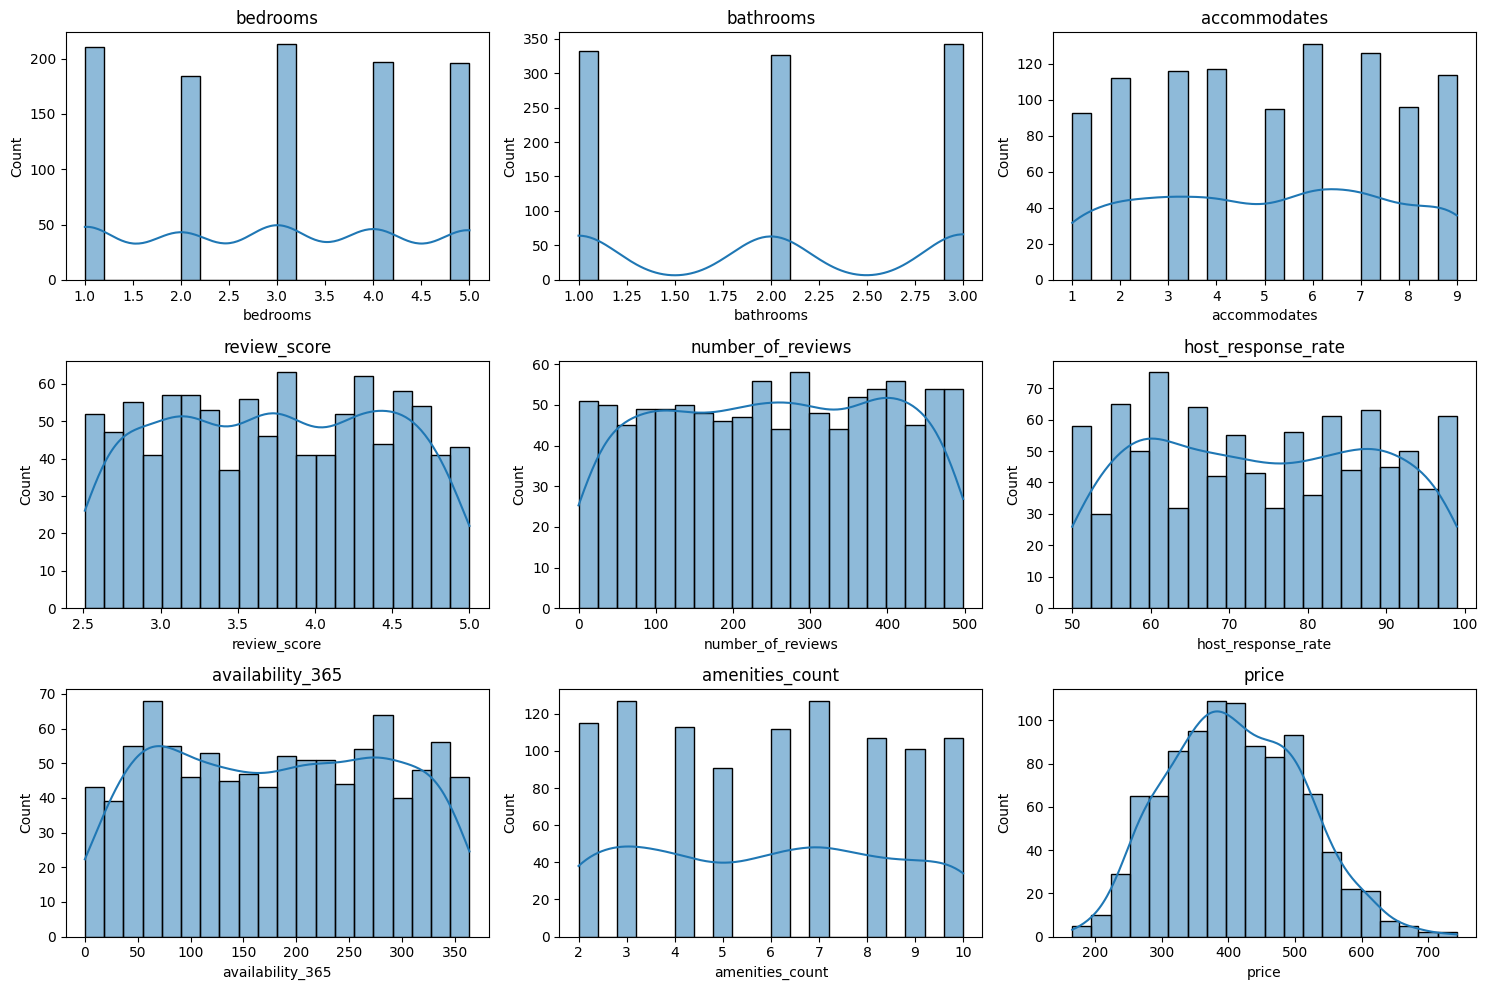

In [10]:

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

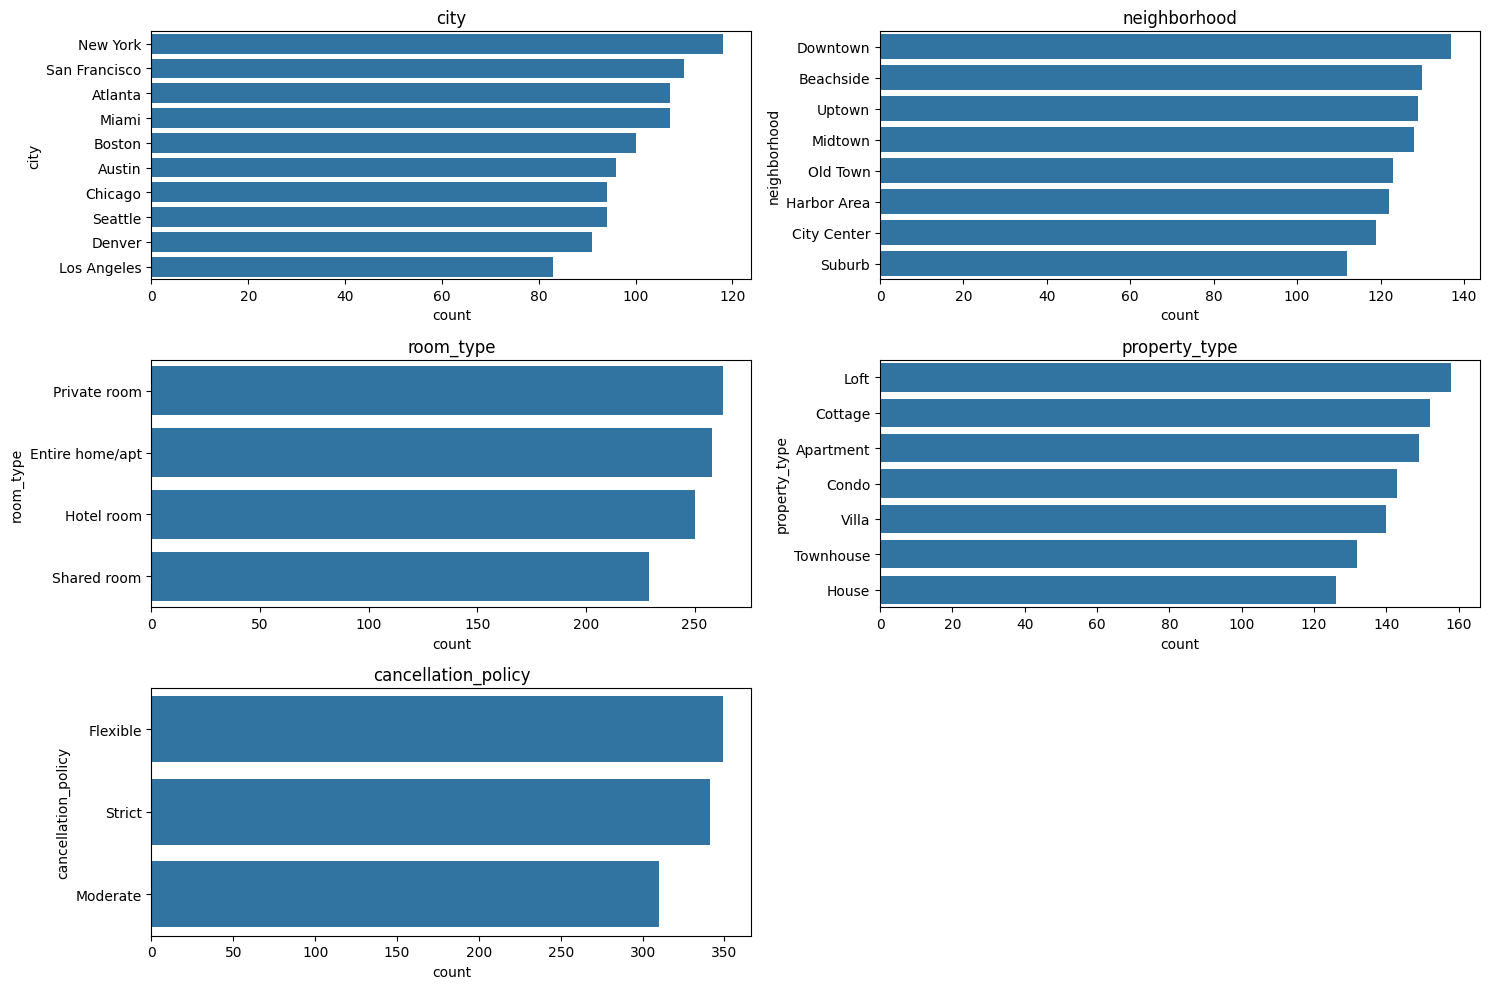

In [11]:
# Count plots for categorical features
categorical_cols = ["city", "neighborhood", "room_type", "property_type", "cancellation_policy"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(col)
plt.tight_layout()
plt.show()


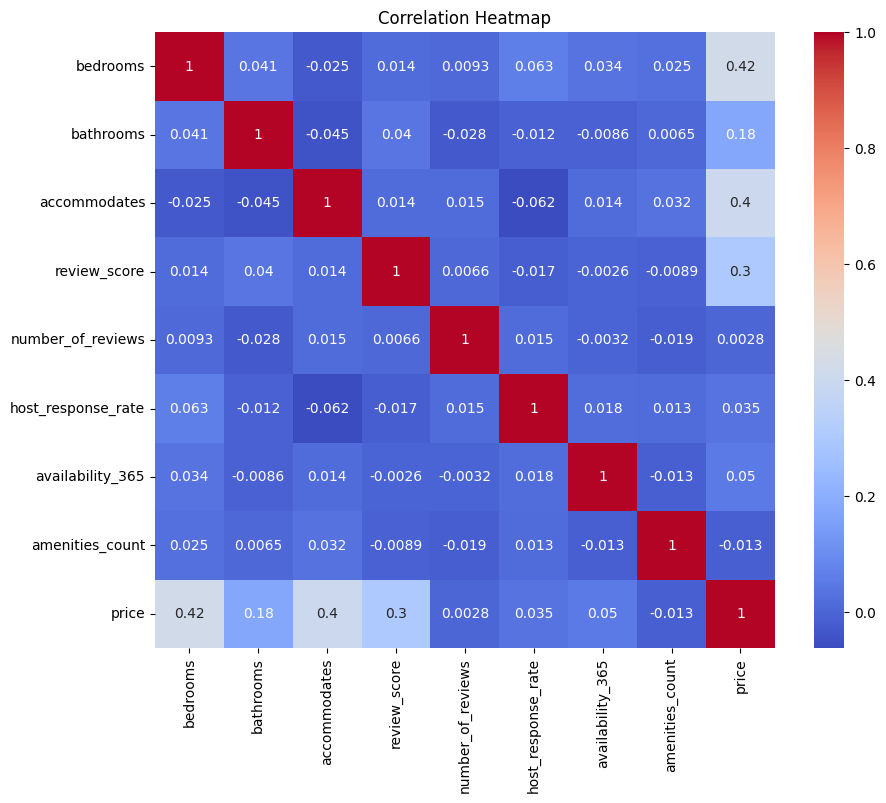

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Average price by city:


city
San Francisco    510.085545
New York         477.117712
Miami            470.920374
Los Angeles      439.002289
Boston           418.668300
Seattle          408.249362
Austin           386.503125
Chicago          351.659362
Denver           324.476264
Atlanta          298.241402
Name: price, dtype: float64

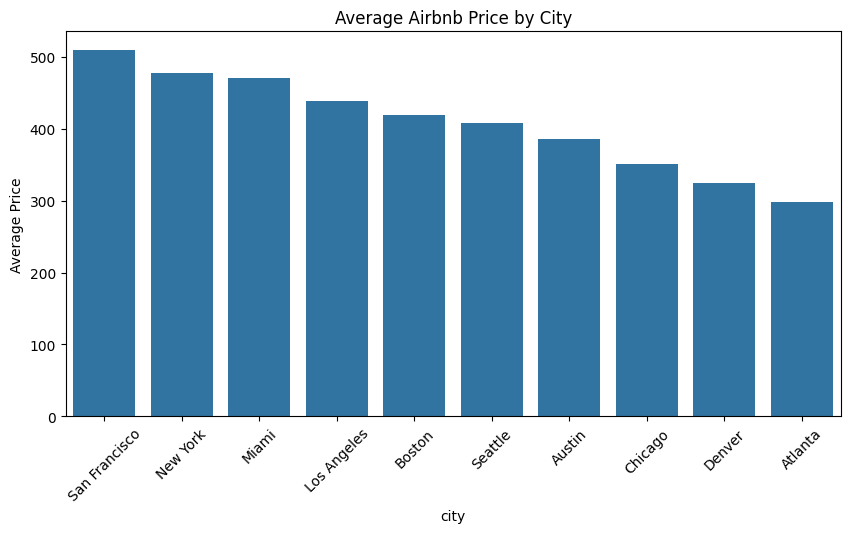

In [13]:
# Top cities and their average prices
city_price = df.groupby("city")["price"].mean().sort_values(ascending=False)
print("Average price by city:")
display(city_price)

plt.figure(figsize=(10,5))
sns.barplot(x=city_price.index, y=city_price.values)
plt.xticks(rotation=45)
plt.ylabel("Average Price")
plt.title("Average Airbnb Price by City")
plt.show()


Average price by room type:


room_type
Shared room        423.658297
Entire home/apt    419.291318
Private room       407.213726
Hotel room         395.138280
Name: price, dtype: float64

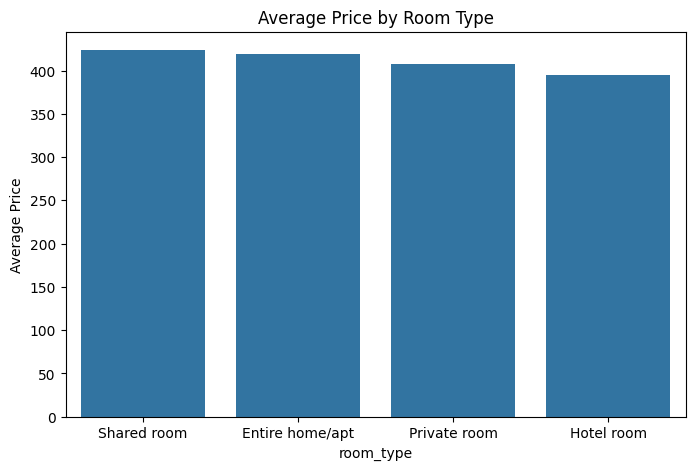

In [14]:

# Average price by room type
room_price = df.groupby("room_type")["price"].mean().sort_values(ascending=False)
print("\nAverage price by room type:")
display(room_price)

plt.figure(figsize=(8,5))
sns.barplot(x=room_price.index, y=room_price.values)
plt.ylabel("Average Price")
plt.title("Average Price by Room Type")
plt.show()

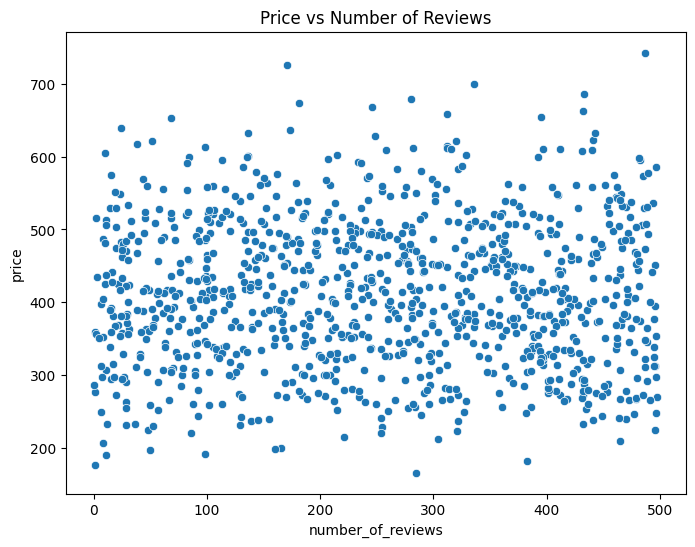

In [15]:
# Price vs Number of Reviews
plt.figure(figsize=(8,6))
sns.scatterplot(x="number_of_reviews", y="price", data=df)
plt.title("Price vs Number of Reviews")
plt.show()

## Training the recommender model

In [16]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [17]:
print("Dataset loaded. Shape:", df.shape)

Dataset loaded. Shape: (1000, 17)


In [18]:
# Encode categorical columns for the model
categorical_cols = ["city", "neighborhood", "room_type", "property_type", "cancellation_policy"]

In [19]:
# Initialize LabelEncoders
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # save encoder for later use
print("\nCategorical columns encoded.")


Categorical columns encoded.


In [20]:
# Define features and target
# We will predict price as the target for now
X = df.drop(columns=["listing_id", "price"])
y = df["price"]

In [21]:
# Split into training and testing sets 80% training 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (800, 15)
Testing set shape: (200, 15)


In [22]:
# Import required libraries for modeling
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
# Initialize the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,  # number of trees
    random_state=42,
    n_jobs=-1          # use all cores
)

In [24]:
# Train the model
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [25]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

In [26]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


Model Evaluation:
RMSE: 47.04
R² Score: 0.76



Feature Importances:


city                   0.381296
bedrooms               0.191079
accommodates           0.138495
review_score           0.120497
availability_365       0.022437
number_of_reviews      0.022268
latitude               0.021856
longitude              0.018579
host_response_rate     0.017231
bathrooms              0.015982
amenities_count        0.013603
neighborhood           0.012405
property_type          0.011986
room_type              0.007681
cancellation_policy    0.004606
dtype: float64

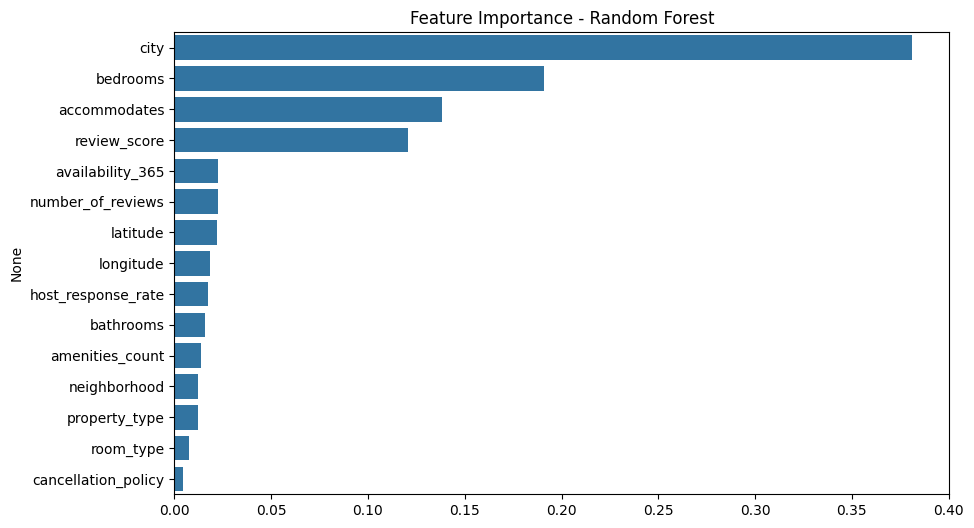

In [27]:
# Feature importance (to see which features are most impactful)
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print("\nFeature Importances:")
display(importances)

# Optional: plot feature importance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.show()

## Saving the model

In [29]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "rf_airbnb_model.pkl")
print("Random Forest model saved as rf_airbnb_model.pkl")

# Save the label encoders for categorical columns
joblib.dump(label_encoders, "label_encoders.pkl")
print("Label encoders saved as label_encoders.pkl")


Random Forest model saved as rf_airbnb_model.pkl
Label encoders saved as label_encoders.pkl


## Gui build for the model 